In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import phi2D_utilities as utils;
from matplotlib.animation import FuncAnimation;
from matplotlib.gridspec import GridSpec;

# Styling.
plt.style.use("ggplot");

In [2]:
# Test inputs - delete when done!
directory_path = "/zhisongqu_data/seth/GYSELA/raw/batch_11/DN_DELTASCAN_A3_QUIESCENT_0.0";
dt_diag = reader.fetch_dt_diag(directory_path);
jacobian_dictionary = reader.fetch_jacobian(directory_path);

In [3]:
class Phi2DAnimator:

	def __init__(self, directory_path, jacobian_dictionary, dt_diag, time_steps, title_prefix, output_path, update_clim = False):
		
		# Standard constructor boilerplate.
		self.directory_path = directory_path;
		self.jacobian_dictionary = jacobian_dictionary;
		self.dt_diag = dt_diag;
		self.time_steps = time_steps;
		self.title_prefix = title_prefix;
		self.output_path = output_path;
		self.update_clim = update_clim;
		initial_phi_dictionary, initial_dataset, initial_time = self._load_phi_dictionary_with_time(time_steps[0]);
		self.mesh_grid = utils.generate_xy_grid(initial_dataset);
		self._initialise_figure(initial_phi_dictionary, initial_time);

	def _load_phi_dictionary_with_time(self, time_step):

		filename = f"Phi2D_d{time_step:05d}.h5";
		path = f"{self.directory_path}/sp0/Phi2D/{filename}";
		time_in_code_units = time_step * self.dt_diag;

		initial_dataset = reader.fetch_data_from_h5(path, dimensions=["zeta", "r", "theta"]);
		phi_dictionary = utils.generate_phi_dictionary(initial_dataset, self.jacobian_dictionary);
		print(f"Loaded time-step {time_step} from {filename}.");
		return phi_dictionary, initial_dataset, time_in_code_units;

	def _initialise_figure(self, initial_phi_dictionary, time_in_code_units):

		self.meshes = [];
		self.fig = plt.figure(figsize = (12, 10));
		grid = GridSpec(2, 2, figure = self.fig, wspace = 0.3, hspace = 0.3);
		axes = [
			self.fig.add_subplot(grid[0, 0]),
			self.fig.add_subplot(grid[0, 1]),
			self.fig.add_subplot(grid[1, 0]),
			self.fig.add_subplot(grid[1, 1])
		];

		for index, dictionary in enumerate(initial_phi_dictionary.values()):

			ax = axes[index];
			phi_values = dictionary["data"].values;
			title = dictionary["title"];

			vmax = np.max(np.abs(phi_values));
			mesh = ax.pcolormesh(self.mesh_grid[0], self.mesh_grid[1], phi_values, vmax = vmax, vmin = -vmax, shading = "auto", cmap = "RdBu_r");
			ax.set_aspect("equal");
			ax.set_title(title, pad = 20);
			ax.axis("off");
		
			self.fig.colorbar(mesh, ax = ax, fraction = 0.05, pad = 0.3);
			self.meshes.append(mesh);
	
		self._update_title(time_in_code_units);
	
	def _update_frame(self, time_step):
		
		phi_dictionary, _, time_in_code_units = self._load_phi_dictionary_with_time(time_step);

		for index, dictionary in enumerate(phi_dictionary.values()):

			phi_values = dictionary["data"].values;
			mesh = self.meshes[index];
			mesh.set_array(phi_values.ravel());

			current_max = np.nanmax(np.abs(phi_values));

			if current_max > 0 and self.update_clim:

				mesh.set_clim(vmin = -current_max, vmax = current_max);
		
		self._update_title(time_in_code_units);
		print(f"Loaded frame for time-step {time_step}.");
		return self.meshes;

	def _update_title(self, time_in_code_units):

		if time_in_code_units != self.time_steps[0] * self.dt_diag:

			self.suptitle.set_text(rf"$\Phi$ snapshots, {self.title_prefix}, t = {time_in_code_units} $\omega_{{ci}}^{{-1}}$");
			return;

		self.suptitle = self.fig.suptitle(rf"$\Phi$ snapshots, {self.title_prefix}, t = {time_in_code_units} $\omega_{{ci}}^{{-1}}$", fontsize = 14);

	def animate_and_save(self, fps = 30, dpi = 150):

		print(f"Animating {len(self.time_steps)} frames...");
		anim = FuncAnimation(
			self.fig,
			self._update_frame,
			frames = self.time_steps,
			interval = 1000 / fps,
			blit = False
		);

		anim.save(self.output_path, writer = "ffmpeg", dpi = dpi);
		print(f"Animation saved to {self.output_path}.");
		plt.close(self.fig);

Loaded time-step 0 from Phi2D_d00000.h5.
Animating 201 frames...
Loaded time-step 0 from Phi2D_d00000.h5.
Loaded frame for time-step 0.


/home/thur0011/GYSELA/custom_scripts/GYSELA_utils/post-processing/scripts/phi2D_utilities.py:195: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  return np.linspace(0, 2 * np.pi, phi2D_dataset.dims["theta"]);
/home/thur0011/GYSELA/custom_scripts/GYSELA_utils/post-processing/scripts/phi2D_utilities.py:199: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  return np.linspace(0, minor_radius, phi2D_dataset.dims["r"]);
/tmp/ipykernel_1295221/20262631.py:47: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may l

Loaded time-step 0 from Phi2D_d00000.h5.
Loaded frame for time-step 0.
Loaded time-step 1 from Phi2D_d00001.h5.
Loaded frame for time-step 1.
Loaded time-step 2 from Phi2D_d00002.h5.
Loaded frame for time-step 2.
Loaded time-step 3 from Phi2D_d00003.h5.
Loaded frame for time-step 3.
Loaded time-step 4 from Phi2D_d00004.h5.
Loaded frame for time-step 4.
Loaded time-step 5 from Phi2D_d00005.h5.
Loaded frame for time-step 5.
Loaded time-step 6 from Phi2D_d00006.h5.
Loaded frame for time-step 6.
Loaded time-step 7 from Phi2D_d00007.h5.
Loaded frame for time-step 7.
Loaded time-step 8 from Phi2D_d00008.h5.
Loaded frame for time-step 8.
Loaded time-step 9 from Phi2D_d00009.h5.
Loaded frame for time-step 9.
Loaded time-step 10 from Phi2D_d00010.h5.
Loaded frame for time-step 10.
Loaded time-step 11 from Phi2D_d00011.h5.
Loaded frame for time-step 11.
Loaded time-step 12 from Phi2D_d00012.h5.
Loaded frame for time-step 12.
Loaded time-step 13 from Phi2D_d00013.h5.
Loaded frame for time-step 13

OSError: Unable to synchronously open file (truncated file: eof = 50873, sblock->base_addr = 0, stored_eof = 2164808)

Loaded time-step 0 from Phi2D_d00000.h5.
Loaded frame for time-step 0.


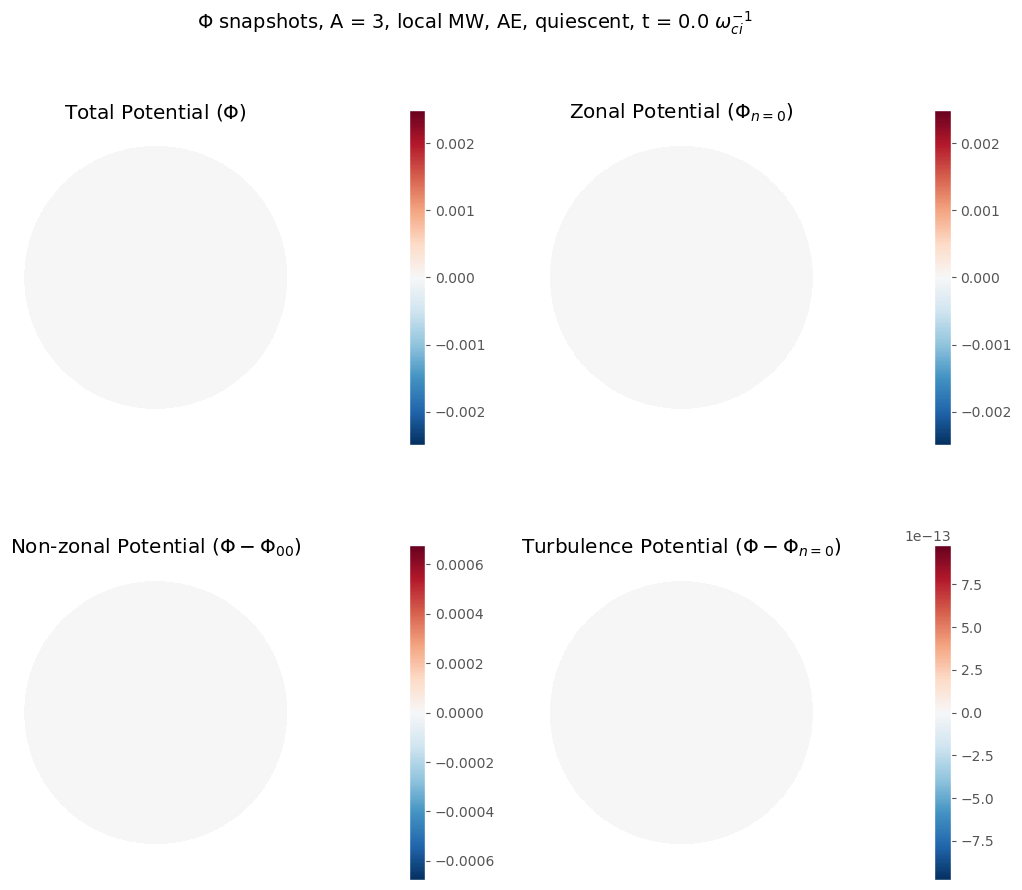

In [4]:
time_steps = range(0, 201, 1);
title_prefix = "A = 3, local MW, AE, quiescent";
output_path = "/home/thur0011/GYSELA/custom_scripts/GYSELA_utils/post-processing/output/A3_quiescent_255x512_phi2D_evolution.mp4";

animator_instance = Phi2DAnimator(
	directory_path = directory_path,
	jacobian_dictionary = jacobian_dictionary,
	dt_diag = dt_diag,
	time_steps = time_steps,
	title_prefix = title_prefix,
	output_path = output_path,
	update_clim = True
);

animator_instance.animate_and_save(fps = 20, dpi = 150);